### Notebook to plot time-height series from BOWTIE sounding data.

James Ruppert  
jruppert@ou.edu  
8/19/24

### Main settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.dates as mdates
from thermo_functions import *
import subprocess, cmocean
import xarray as xr
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from time_series_diag import *
from bowtie_read_data import *
from vertical_int import *

In [2]:
# Soundings
# snd_asc, snd_files, times_asc = read_bowtie_soundings(search_string = 'ascen')
snd_asc = read_soundings(platform='RV_Meteor', ascent=0)
times_asc = snd_asc['times']
# soundings, snd_files, times_snd = read_bowtie_soundings(search_string = 'descen')
hght = snd_asc['hght']

### Compute diagnostics

In [3]:
# Vertical mass-weighted integral
#   inputs:
#       tmpk:   temperature [K]
#       mr:     water vapor mixing ratio [kg/kg]
#       p:      pressure [Pa]
#       hght:   height [m]
#   options:
#       minpres: set this to minimum pressure to integrate over [Pa]
# def vert_integral(invar, tmpk, mr, p, hght, minpres=0):
#     rho = density_moist(tmpk, mr, p) # kg/m3
#     dz = hght[1]-hght[0] # m
#     var_int = np.nansum(invar*rho, axis=1, where=(p > minpres))*dz
#     var_int[ np.where(var_int == 0) ] = np.nan
#     return var_int

In [4]:
# Constants
cp=1004.  # J/K/kg
cpl=4186. # J/k/kg
cpv=1885. # J/K/kg
lv0=2.5e6 # J/kg
g = 9.81 # m/s2
# Latent heat of vaporization
lv = lv0 - (cpl-cpv)*(snd_asc['tmpk']-273.15)

minpres=50e2 # Upper pressure bound for vertical integrals [Pa]

# MSE
dse = cp*snd_asc['tmpk'] + g*hght[np.newaxis,:]
lvq= lv*snd_asc['mr']
mse = dse + lvq

# Static stability
theta = theta_dry(snd_asc['tmpk'], snd_asc['p'])
def smooth_theta(invar, nz_smooth=10):
    invar_pd = pd.DataFrame(invar.transpose())
    invar_pd = invar_pd.rolling(window=nz_smooth, center=True, closed='both', min_periods=3).mean().transpose()
    return np.squeeze(np.array(invar_pd))
for ido in range(3):
    theta = smooth_theta(theta, nz_smooth=10)
dthdz = np.gradient(theta, hght, axis=1) # K/m
# for ido in range(10):
dthdz = smooth_theta(dthdz, nz_smooth=20)

tmpk_ddz = np.copy(snd_asc['tmpk'])
for ido in range(3):
    tmpk_ddz = smooth_theta(tmpk_ddz, nz_smooth=10)
dtdz = np.gradient(tmpk_ddz, hght, axis=1) # K/m
dtdz = smooth_theta(dtdz, nz_smooth=20)

# CWV/PW
# 1/g int(q)dp = s2/m * kg/m/s2 --> kg/m2 --> x1/rho_l --> 10^-3 kg/m2*m3/kg --> 10^-3m = mm
# int<q*rho>dz = kg/m3*m = kg/m2 = mm
cwv = vert_integral(snd_asc) # mm or kg/m2

From PICCOLO #science canvas, 10/27/24

Possible CasesPP/Eastern

1. August 21 HALO flight (within circle with rain) (animation)
2. August 24 gust front/squall line (animation) 
3. August 25 thunderstorm (thunder and lightning at ship)  (animation)
4. August 27 Band of convection in a tight line through the late evening of August 26th and the early morning of August 27th. 


 AP/Eastern

1. August 29 a skinny line of convection evolves into a wider cluster over a period of about 4 hours. 
2. August 31 HALO flight (two overpasses with rain, EC overpass), scattered rain throughout day (animation)
3. September 2 MCS – first time truly under contiguous cold cloud tops (animation)
4. September 3 HALO flight (center of circle, two overpasses, EC overpass) (animation)


 AP/Central

1. September 6-11 ITCZ transect (09/06, 09/07, 09/08, 09/09, 09/10, 09/11)
2. September 8-9 west of Invest 92L (8 – chasing same rainband all day, squall line in morning) (09/08, 09/09) 
3. September 10-11 between Invest 92L and 93L (10 – widespread stratiform with embedded deep convection, 11 – rainy in morning, strong winds) (09/10, 09/11)
4. September 11 in SW-NE elongated trough of Invest 93L/TD 7 – rainy in morning, strong winds. (09/11)


 AP/Western

1. September 19 HALO flight (center of circle, two overpasses, scattered convection early in the day, then more organized MCS in the afternoon, despite dry conditions and meh satellite. Main action was line from BB to Gordon. ) (animation)
2. September 22 Convective life cycle. overnight and morning, two tiny cells that merged together into MCS, transition to stratiform. 6 hour life cycle, good for microphysics. (partial animation- not very informative because I am missing a majority of the day)

In [5]:
def add_cases(ax):
    dates = [
        [np.datetime64('2024-08-21T00:00:00'),np.datetime64('2024-08-22T00:00:00')],
        [np.datetime64('2024-08-24T00:00:00'),np.datetime64('2024-08-25T00:00:00')],
        [np.datetime64('2024-08-25T00:00:00'),np.datetime64('2024-08-26T00:00:00')],
        [np.datetime64('2024-08-26T00:00:00'),np.datetime64('2024-08-27T00:00:00')],
        [np.datetime64('2024-08-29T00:00:00'),np.datetime64('2024-08-30T00:00:00')],
        [np.datetime64('2024-08-31T00:00:00'),np.datetime64('2024-09-01T00:00:00')],
        [np.datetime64('2024-09-02T00:00:00'),np.datetime64('2024-09-03T00:00:00')],
        [np.datetime64('2024-09-03T00:00:00'),np.datetime64('2024-09-04T00:00:00')],
        [np.datetime64('2024-09-06T00:00:00'),np.datetime64('2024-09-12T00:00:00')],
        [np.datetime64('2024-09-08T00:00:00'),np.datetime64('2024-09-10T00:00:00')],
        [np.datetime64('2024-09-10T00:00:00'),np.datetime64('2024-09-12T00:00:00')],
        [np.datetime64('2024-09-19T00:00:00'),np.datetime64('2024-09-20T00:00:00')],
        [np.datetime64('2024-09-22T00:00:00'),np.datetime64('2024-09-23T00:00:00')],
    ]

    # for i, idate in dates:
    for i, idate in enumerate(dates):
        # print(idate)
        ymin = 0.1 * (i % 10)
        ymax = ymin + 0.1
        # ax.axvspan(idate[0], idate[1], color='black', zorder=0, alpha=0.25)
        ax.axvspan(idate[0], idate[1], color='black', zorder=0, alpha=0.25, ymin=ymin, ymax=ymax)
        # ax.axvline(idate[0], color='black', zorder=1, linewidth=0.5, ymin=ymin, ymax=ymax)
        # ax.axvline(idate[1], color='black', zorder=1, linewidth=0.5, ymin=ymin, ymax=ymax)

    return None

---
### Plotting routines

#### Plot functions

In [6]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 12}

rc('font', **font)

# sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})

In [7]:
# def do_smooth(invar, nt_smooth=3, nz_smooth=10):
def do_smooth(invar, nt_smooth=8, nz_smooth=10):
    # Use Pandas to compute rolling average
    invar_pd = pd.DataFrame(invar)
    var_sm1 = invar_pd.rolling(window=nt_smooth, center=True, closed='both', min_periods=3).mean()
    # var_trns = var_sm1.transpose()
    # var_sm = var_trns.rolling(window=nz_smooth, center=True, closed='both', min_periods=3).mean()
    # var_sm = var_sm1.transpose()
    # return np.squeeze(np.array(var_sm.transpose()))
    return np.squeeze(np.array(var_sm1))
# def do_smooth(invar, nt_smooth=3, nz_smooth=10):
def do_smooth_2d(invar, nt_smooth=8):
    # Use Pandas to compute rolling average
    invar_pd = pd.DataFrame(invar)
    var_sm = invar_pd.rolling(window=nt_smooth, center=True, closed='both', min_periods=3).mean()
    return np.squeeze(np.array(var_sm))

In [8]:
def plot_time_height(figdata, smooth=False, top=18, do_log=False):

    fig_x = 9
    fig_y = 3.5
    fig, ax = plt.subplots(figsize=(fig_x,fig_y), layout="constrained",) # row, column

    ax.set_title(figdata['fig_title'])

    ax.set_ylabel('Height [km]')
    ax.set_ylim(0,top)
    # ax.set_xlim(figdata['xlim'])
    ax.set_xlabel('Date [UTC]')

    ax.grid(True, axis='x', color='0.55', linewidth=0.5, zorder=4)
    ax.grid(True, axis='y', color='0.55', linewidth=0.5, zorder=4)#, which='both')

    # Plot variable
    xdim=figdata['time']
    pltvar = figdata['pltvar']
    if smooth:
        pltvar = do_smooth(pltvar)

    # norm=colors.Normalize(np.min(figdata['clevels']), np.max(figdata['clevels']))
    # im = ax.pcolormesh(np.repeat(xdim[:,np.newaxis],len(hght),axis=1), np.repeat(hght[np.newaxis,:]*1e-3,len(xdim),axis=0), pltvar, cmap=figdata['cmap'], shading='gouraud', norm=norm)#figdata['norm'])
    im = ax.contourf(xdim, hght*1e-3, pltvar.transpose(), figdata['clevels'],
                    extend=figdata['extend'], cmap=figdata['cmap'], zorder=0)#, norm=norm)
    fig.colorbar(im, ax=ax, label=figdata['units'], ticks=ticker.AutoLocator())#, shrink=0.6)

    # Line contours
    im = ax.contour(xdim, hght*1e-3, pltvar.transpose(), figdata['clevels_line'],
                    colors=figdata['clevels_line_color'],linewidths=0.6, zorder=1)

    # 0ºC level
    hght0c = snd_asc['hght_0c']*1e-3
    if smooth:
        invar_pd = pd.DataFrame(hght0c)
        nt_smooth=3
        invar_sm = invar_pd.rolling(window=nt_smooth, center=True, closed='both', min_periods=3).mean()
        hght0c=np.squeeze(np.array(invar_sm))
    # ax.plot(figdata['time'], hght0c, color='#d62728', zorder=3, linewidth=2)

    # Time labels
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    plt.show()
    plt.close()
    return

In [9]:
def plot_time_height_subpanel(figdata, smooth=False, cwv=None, do_log=False, top=18):

    fig_x = 9
    # fig_y = 3.5
    # fig, ax = plt.subplots(figsize=(fig_x,fig_y), layout="constrained",) # row, column
    fig_y = 5.5
    fig, axs = plt.subplots(2, 1, figsize=(fig_x,fig_y), height_ratios=[.6,.4], layout='constrained',squeeze=True)

    axs[0].set_title(figdata['fig_title'])

    axs[0].set_ylabel('Height [km]')
    axs[0].set_ylim(0,top)
    axs[0].set_xlim(figdata['xlim'])
    # axs[0].set_xlabel('Date')

    axs[0].grid(True, axis='x', color='0.55', linewidth=0.5, zorder=4)
    axs[0].grid(True, axis='y', color='0.55', linewidth=0.5, zorder=4)#, which='both')

    # Plot variable
    xdim=figdata['time']
    pltvar = figdata['pltvar']
    if smooth:
        pltvar = do_smooth(pltvar)

    # norm=colors.Normalize(np.min(figdata['clevels']), np.max(figdata['clevels']))
    # im = ax.pcolormesh(np.repeat(xdim[:,np.newaxis],len(hght),axis=1), np.repeat(hght[np.newaxis,:]*1e-3,len(xdim),axis=0), pltvar, cmap=figdata['cmap'], shading='gouraud', norm=norm)#figdata['norm'])
    im = axs[0].contourf(xdim, hght*1e-3, pltvar.transpose(), figdata['clevels'],
                    extend=figdata['extend'], cmap=figdata['cmap'], zorder=0)#, norm=figdata['norm'])
    fig.colorbar(im, ax=axs[0], label=figdata['units'], ticks=ticker.AutoLocator())#, shrink=0.6)

    # Line contours
    im = axs[0].contour(xdim, hght*1e-3, pltvar.transpose(), figdata['clevels_line'],
                    colors=figdata['clevels_line_color'],linewidths=0.6, zorder=1)

    # 0ºC level
    hght0c = snd_asc['hght_0c']*1e-3
    if smooth:
        invar_pd = pd.DataFrame(hght0c)
        nt_smooth=3
        invar_sm = invar_pd.rolling(window=nt_smooth, center=True, closed='both', min_periods=3).mean()
        hght0c=np.squeeze(np.array(invar_sm))
    # ax.plot(figdata['time'], hght0c, color='#d62728', zorder=3, linewidth=2)

    # Time labels
    axs[0].xaxis.set_major_locator(mdates.AutoDateLocator())
    axs[0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[0].xaxis.get_major_locator()))
    # axs[0].get_xaxis().set_ticks([' ', ' ',' ',' ',' ',' ',' ',' '])

    # Hide labels
    axs[0].xaxis.set_ticklabels([])

    ##################################################

    # CWV SUBPANEL
    axs[1].set_ylabel('IWV [mm]')
    axs[1].set_ylim(48,66)

    # Time labels
    axs[1].set_xlim(figdata['xlim'])
    axs[1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axs[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[0].xaxis.get_major_locator()))

    cwv_plt = np.copy(cwv)
    if smooth:
        cwv_plt = do_smooth_2d(cwv_plt)
    axs[1].plot(xdim, cwv_plt, '-k')
    axs[1].set_xlabel('Date')

    add_cases(axs[1])
    # axs[1].axhline(y=48, color='red', linewidth=0.8, zorder=0)

    plt.show()
    plt.close()
    return

In [10]:
def plot_time_height_multipanel(figdata, smooth=False, cwv=None, do_log=False, top=18):

    fig_x = 9
    fig_y = 12
    fig, axs = plt.subplots(5, 1, figsize=(fig_x,fig_y), 
                            # height_ratios=[3,3,3,3,1.8], 
                            height_ratios=[3,3,3,3,3], 
                            layout='constrained',squeeze=True)

    xdim=figdata['time']

    for iax in range(4):

        axs[iax].set_title(figdata['fig_title'][iax])
        axs[iax].set_ylabel('Height [km]')
        axs[iax].set_ylim(0,top)
        axs[iax].set_xlim(figdata['xlim'])

        axs[iax].grid(True, axis='x', color='0.55', linewidth=0.5, zorder=4)
        axs[iax].grid(True, axis='y', color='0.55', linewidth=0.5, zorder=4)#, which='both')

        pltvar = figdata['pltvar'][iax]
        if smooth:
            pltvar = do_smooth(pltvar)
        im = axs[iax].contourf(xdim, hght*1e-3, pltvar.transpose(), figdata['clevels'][iax],
                        extend=figdata['extend'][iax], cmap=figdata['cmap'][iax], zorder=0)#, norm=figdata['norm'])
        fig.colorbar(im, ax=axs[iax], label=figdata['units'][iax], ticks=ticker.AutoLocator())#, shrink=0.6)

        # Line contours
        im = axs[iax].contour(xdim, hght*1e-3, pltvar.transpose(), figdata['clevels_line'][iax],
                        colors='black',linewidths=0.6, zorder=1)

        # Time labels
        axs[iax].xaxis.set_major_locator(mdates.AutoDateLocator())
        axs[iax].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[iax].xaxis.get_major_locator()))

        # Hide labels
        axs[iax].xaxis.set_ticklabels([])

        axs[iax].set_xlim(figdata['xlim'])

    ##################################################

    # CWV SUBPANEL
    axs[-1].set_ylabel('IWV [mm]')
    # axs[-1].set_ylim(48,66)
    axs[-1].set_ylim(47,72)
    axs[-1].grid(True, axis='x', color='0.55', linewidth=0.5)
    axs[-1].grid(True, axis='y', color='0.55', linewidth=0.5)

    # Time labels
    axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axs[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[3].xaxis.get_major_locator()))
    axs[-1].set_xlim(figdata['xlim'])

    cwv_plt = np.copy(cwv)
    if smooth:
        cwv_plt = do_smooth_2d(cwv_plt)
    axs[-1].plot(xdim, cwv_plt, '-k')
    axs[-1].set_xlabel('Date')

    # axs[1].axhline(y=48, color='red', linewidth=0.8, zorder=0)

    plt.show()
    plt.close()
    return

#### Time-height series

##### Multi-panel

/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/numpy/ma/core.py:7229: RuntimeWarning: overflow encountered in power
  result = np.where(m, fa, umath.power(fa, fb)).view(basetype)
/Users/jamesruppert/Library/CloudStorage/OneDrive-UniversityofOklahoma/piccolo-code-jhr/thermo_functions.py:175: RuntimeWarning: overflow encountered in exp
  * np.exp( (lv0 - (cpl-cpv)*((T+T0)-273.15))*rv / ((cp + cpl*rtot)*(T+T0)) )


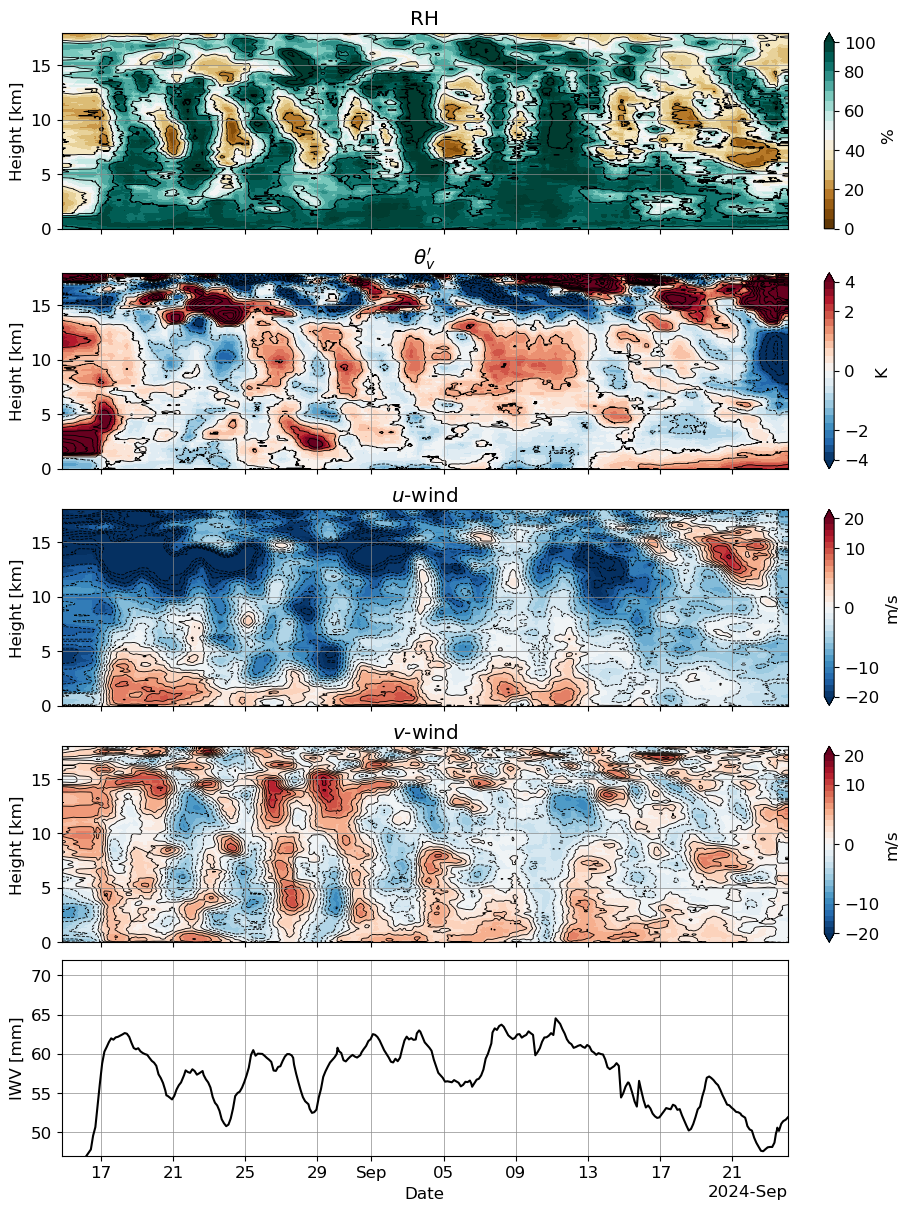

In [11]:
xlim=(times_asc[0],times_asc[-1])
# xlim=(times_asc[-48*2],times_asc[-1])
# xlim=[np.datetime64('2024-08-23T00:00'), np.datetime64('2024-08-27T00:00')]

# Relative humidity
rh_cint = 20
# Theta
thmax=3
tht_cint = 1
# Mixing ratio
qvmax=3
qvcint = 1
# Winds
uvmax=15
uvcint = 2

# Variables
rh_asc = calc_relh(snd_asc['mr'], snd_asc['p'], snd_asc['tmpk'], ice=True)
theta_e = theta_equiv(snd_asc['tmpk'], snd_asc['mr'], snd_asc['mr'], snd_asc['p'])
# theta_e -= (np.nanmean(theta_e, axis=0))[np.newaxis,:]

theta = theta_virtual(snd_asc['tmpk'], snd_asc['mr'], snd_asc['p'])
theta -= (np.nanmean(theta, axis=0))[np.newaxis,:]

qv = snd_asc['mr']*1e3
qv -= (np.nanmean(qv, axis=0))[np.newaxis,:]

dvdt = np.gradient(snd_asc['v'], 3600*3, axis=0)

figdata = {
    'time': times_asc,
    'pltvar': [rh_asc, theta, snd_asc['u'], snd_asc['v'], cwv],
    # 'pltvar': [rh_asc, theta, snd_asc['u'], dvdt, cwv],
    # 'pltvar': [theta_e, theta, snd_asc['u'], snd_asc['v'], cwv],
    # 'pltvar': [theta_e, theta, qv, snd_asc['v'], cwv],
    'fig_title': ['RH', r"$\theta_v'$", '$u$-wind', '$v$-wind'],
    # 'fig_title': [r"$\theta_e'$", r"$\theta_v'$", '$u$-wind', '$v$-wind'],
    # 'fig_title': [r"$\theta_e$", r"$\theta_v'$", '$q_v$', '$v$-wind'],
    'units': ['%', 'K', 'm/s', 'm/s'],
    # 'units': ['K', 'K', 'm/s', 'm/s'],
    # 'units': ['K', 'K', 'g/kg', 'm/s'],
    'cmap': ['BrBG', 'RdBu_r', 'RdBu_r', 'RdBu_r'],
    'clevels': [np.arange(0,100,5), # RH
    # 'clevels': [np.arange(330,355,2), # theta-e
                np.arange(-thmax,thmax+.25,.25),
                np.arange(-uvmax,uvmax+1,1), # u
                # np.arange(-qvmax,qvmax+.25,.25), # qv
                np.arange(-uvmax,uvmax+1,1)], # v
    # 'clevels_line': [np.arange(-tht_cint*10,tht_cint*10,tht_cint), # RH
    'clevels_line': [np.arange(rh_cint,rh_cint*10,rh_cint), # theta-e
    # 'clevels_line': [np.arange(-2*10,2*10,2),
                     np.arange(-tht_cint*10,tht_cint*10,tht_cint),
                     np.arange(-uvcint*10,uvcint*10,uvcint), # u
                    #  np.arange(-qvcint*10,qvcint*10,qvcint), # qv
                     np.arange(-uvcint*10,uvcint*10,uvcint)], # v
    'extend': ['max', 'both', 'both', 'both'],
    # 'extend': ['both', 'both', 'both', 'both'],
    'xlim': xlim,
           }

smoothing=True
# smoothing=False
plot_time_height_multipanel(figdata, cwv=cwv, smooth=smoothing, top=18)

##### RH and T

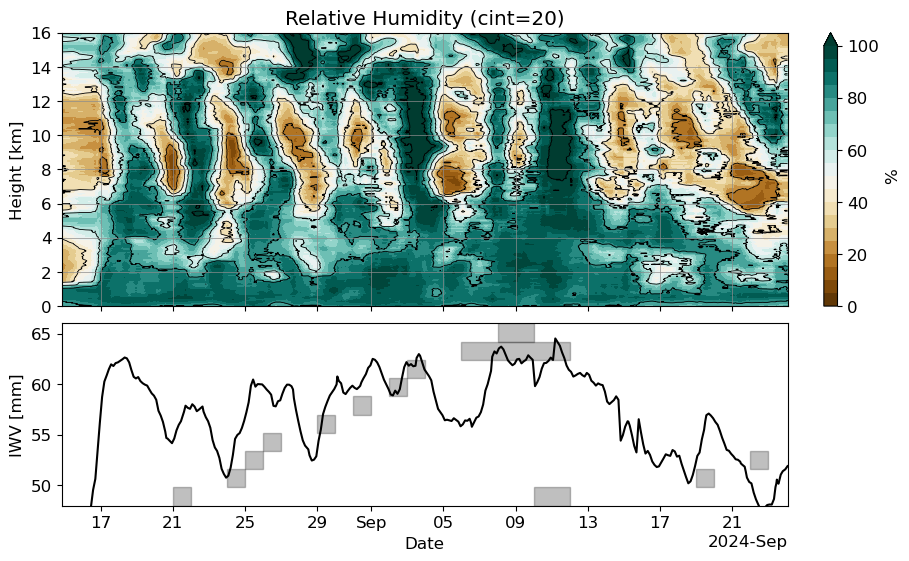

/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/numpy/ma/core.py:7229: RuntimeWarning: overflow encountered in power
  result = np.where(m, fa, umath.power(fa, fb)).view(basetype)
/Users/jamesruppert/Library/CloudStorage/OneDrive-UniversityofOklahoma/piccolo-code-jhr/thermo_functions.py:175: RuntimeWarning: overflow encountered in exp
  * np.exp( (lv0 - (cpl-cpv)*((T+T0)-273.15))*rv / ((cp + cpl*rtot)*(T+T0)) )


In [12]:
xlim=(times_asc[0],times_asc[-1])
# xlim=(times_asc[1],times_asc[-1])
# xlim=(np.datetime64('2024-08-20T06:00'),times_asc[-1])
# xlim=(times_asc[-4*8],times_asc[-1])
# xlim=(np.datetime64('2024-08-22T06:00'),times_asc[-1])
# xlim=(np.datetime64('2024-09-01T00:00'),times_asc[-1])

smoothing=True
# smoothing=False

ztop=16

# Relative humidity

cint_lines = 20
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

rh_asc = calc_relh(snd_asc['mr'], snd_asc['p'], snd_asc['tmpk'], ice=True)

figdata = {
    # 'pltvar': snd_asc['rh'],
    'pltvar': rh_asc,
    'time': times_asc,
    'fig_title': r'Relative Humidity (cint='+str(cint_lines)+')',
    'units': '%',
    'cmap': 'BrBG',
    'clevels': np.arange(0,105,5),
    'clevels_line': contours,
    'clevels_line_color': 'black',
    'extend': 'max',
    'xlim': xlim,
           }

plot_time_height_subpanel(figdata, cwv=cwv, smooth=smoothing, top=ztop)

# cint_lines = 20
# contours = np.arange(cint_lines,cint_lines*10,cint_lines)

# figdata = {
#     'pltvar': snd_asc['rh'],
#     'time': times_asc,
#     'fig_title': r'Relative Humidity (cint='+str(cint_lines)+')',
#     'units': '%',
#     'cmap': 'BrBG',
#     'clevels': np.arange(0,105,5),
#     'clevels_line': contours,
#     'clevels_line_color': 'black',
#     'extend': 'both',
#     'xlim': xlim,
#            }

# plot_time_height(figdata, smooth=smoothing, top=ztop)

cint_lines = 20
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

rh_asc = calc_relh(snd_asc['mr'], snd_asc['p'], snd_asc['tmpk'], ice=True)

figdata = {
    # 'pltvar': snd_asc['rh'],
    'pltvar': rh_asc,
    'time': times_asc,
    'fig_title': r'Relative Humidity (cint='+str(cint_lines)+')',
    'units': '%',
    'cmap': 'BrBG',
    'clevels': np.arange(0,105,5),
    'clevels_line': contours,
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

# plot_time_height(figdata, smooth=smoothing, top=ztop)

# Equivalent Potential Temperature

cint_lines = 1
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

theta_e = theta_equiv(snd_asc['tmpk'], snd_asc['mr'], snd_asc['mr'], snd_asc['p'])
# theta_e -= (np.nanmean(theta_e, axis=0))[np.newaxis,:]

figdata = {
    'pltvar': theta_e,
    'time': times_asc,
    'fig_title': r"$\theta_e'$ (anomaly WRT time mean) (cint="+str(cint_lines)+')',
    'units': 'K',
    'cmap': 'RdBu_r',
    'clevels': np.arange(320,360,2),#np.arange(-3,3.5,.5),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

# plot_time_height(figdata, smooth=smoothing, top=ztop)

# Virtual Potential Temperature

cint_lines = 1
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

# t_asc = np.copy(snd_asc['tmpk'])
# t_asc -= (np.nanmean(t_asc, axis=0))[np.newaxis,:]
theta = theta_virtual(snd_asc['tmpk'], snd_asc['mr'], snd_asc['p'])
theta -= (np.nanmean(theta, axis=0))[np.newaxis,:]

figdata = {
    'pltvar': theta,
    'time': times_asc,
    'fig_title': r"$\theta_v'$ (anomaly WRT time mean) (cint="+str(cint_lines)+')',
    'units': 'K',
    'cmap': 'RdBu_r',
    'clevels': np.arange(-3,3.5,.5),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

# plot_time_height(figdata, smooth=smoothing, top=ztop)

##### MSE and Lq

/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_10248/2577125103.py:7: RuntimeWarning: Mean of empty slice
  mse_asc -= (np.nanmean(mse_asc, axis=0))[np.newaxis,:]


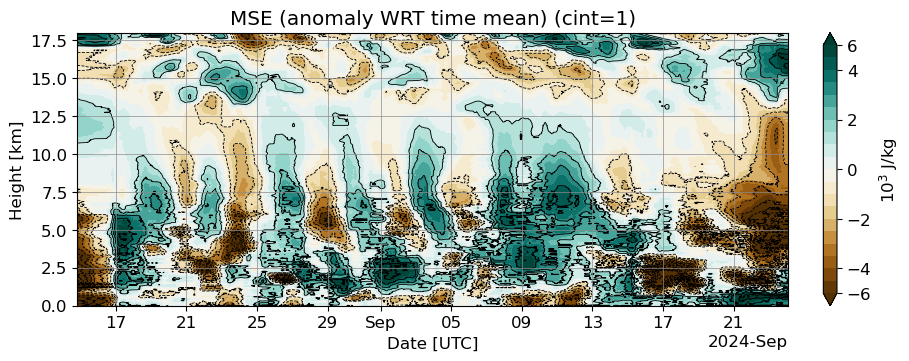

/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_10248/2577125103.py:30: RuntimeWarning: Mean of empty slice
  lvq_asc -= (np.nanmean(lvq_asc, axis=0))[np.newaxis,:]


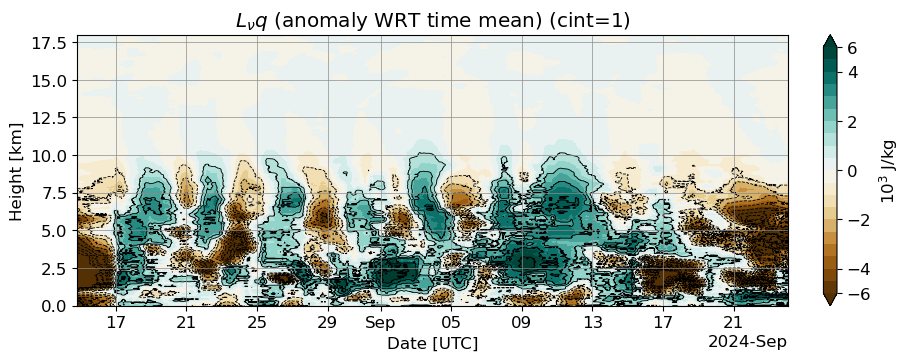

/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_10248/2577125103.py:53: RuntimeWarning: Mean of empty slice
  dse_asc -= (np.nanmean(dse_asc, axis=0))[np.newaxis,:]


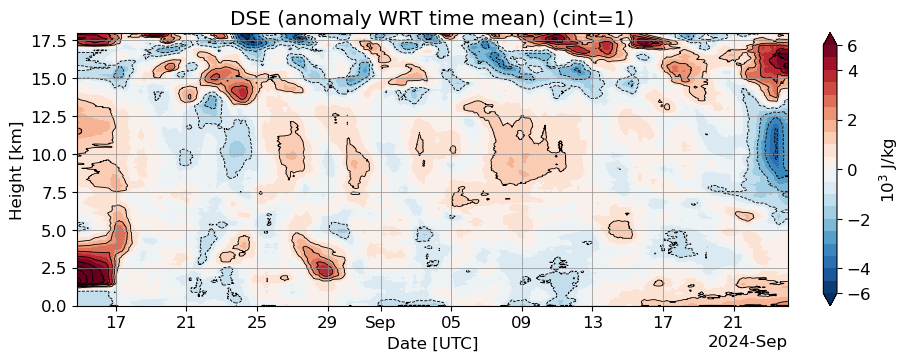

In [13]:
# Moist static energy

cint_lines = 1
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

mse_asc = np.ma.filled(mse, np.nan)
mse_asc -= (np.nanmean(mse_asc, axis=0))[np.newaxis,:]

figdata = {
    'pltvar': mse_asc*1e-3,
    'time': times_asc,
    'fig_title': 'MSE (anomaly WRT time mean) (cint='+str(cint_lines)+')',
    'units': '10$^3$ J/kg',
    'cmap': 'BrBG',
    'clevels': np.arange(-5,5.5,0.5),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

# Lq

cint_lines = 1
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

lvq_asc = np.ma.filled(lvq, np.nan)
lvq_asc -= (np.nanmean(lvq_asc, axis=0))[np.newaxis,:]

figdata = {
    'pltvar': lvq_asc*1e-3,
    'time': times_asc,
    'fig_title': r'$L_{\nu}q$ (anomaly WRT time mean) (cint='+str(cint_lines)+')',
    'units': '10$^3$ J/kg',
    'cmap': 'BrBG',
    'clevels': np.arange(-5,5.5,0.5),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

# cpT

cint_lines = 1
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

dse_asc = np.ma.filled(dse, np.nan)
dse_asc -= (np.nanmean(dse_asc, axis=0))[np.newaxis,:]

figdata = {
    'pltvar': dse_asc*1e-3,
    'time': times_asc,
    'fig_title': 'DSE (anomaly WRT time mean) (cint='+str(cint_lines)+')',
    'units': '10$^3$ J/kg',
    'cmap': 'RdBu_r',
    'clevels': np.arange(-5,5.5,0.5),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

##### Winds

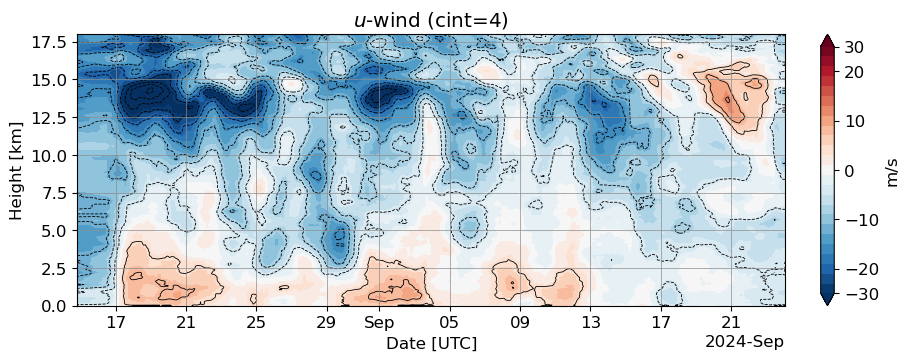

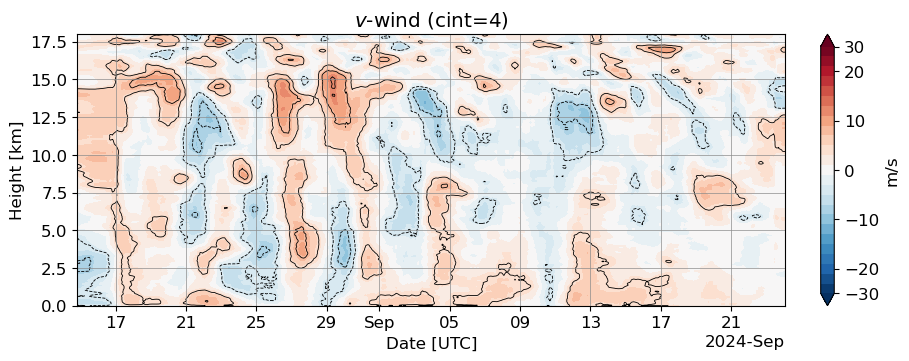

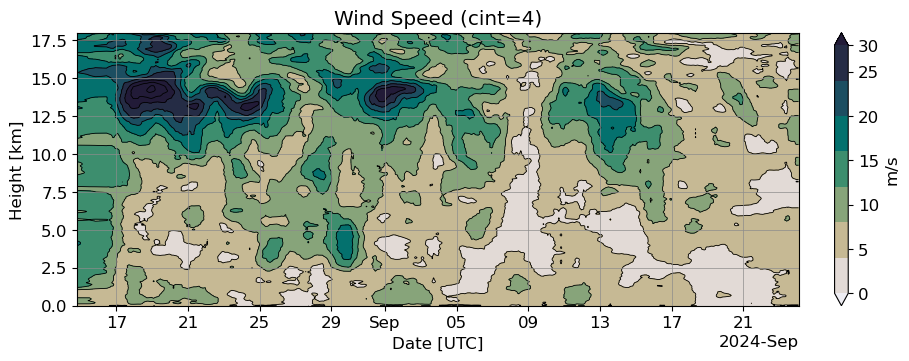

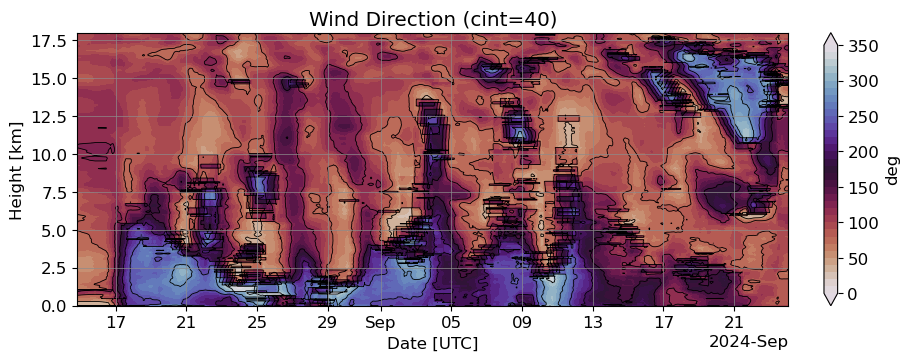

In [14]:
# xlim=(np.datetime64('2024-09-01T00:00'),times_asc[-1])

# Winds

cint_lines = 4
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

figdata = {
    'pltvar': snd_asc['u'],
    'time': times_asc,
    'fig_title': r'$u$-wind (cint='+str(cint_lines)+')',
    'units': 'm/s',
    'cmap': 'RdBu_r',
    'clevels': np.arange(-25,27,2),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

figdata = {
    'pltvar': snd_asc['v'],
    'time': times_asc,
    'fig_title': r'$v$-wind (cint='+str(cint_lines)+')',
    'units': 'm/s',
    'cmap': 'RdBu_r',
    'clevels': np.arange(-25,27,2),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

cint_lines = 4
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

figdata = {
    'pltvar': np.sqrt(snd_asc['u']**2 + snd_asc['v']**2),
    'time': times_asc,
    'fig_title': 'Wind Speed (cint='+str(cint_lines)+')',
    'units': 'm/s',
    'cmap': cmocean.cm.rain,
    'clevels': np.arange(0,30,4),
    'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

cint_lines = 40
contours = np.arange(cint_lines,cint_lines*50,cint_lines)

figdata = {
    'pltvar': snd_asc['wdir'],
    'time': times_asc,
    'fig_title': 'Wind Direction (cint='+str(cint_lines)+')',
    'units': 'deg',
    'cmap': 'twilight_r',
    'clevels': np.arange(0,360,10),
    'clevels_line': contours,
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=smoothing)

##### Static stability

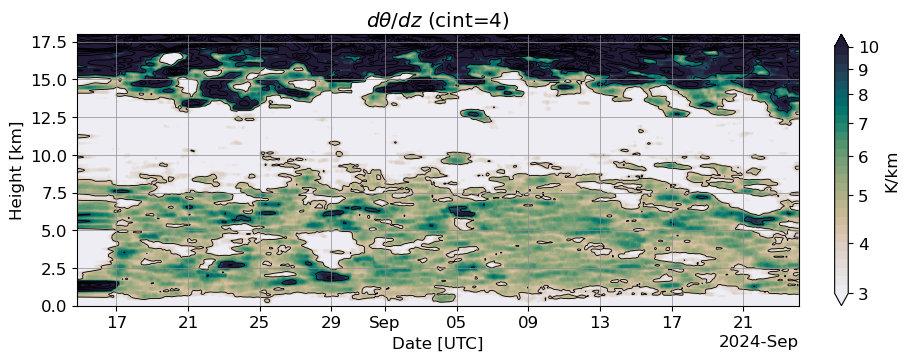

In [15]:
# d(th)/dz

cint_lines = 4
contours = np.arange(cint_lines,cint_lines*10,cint_lines)

# dthdz_asc = np.copy(dthdz)
# dthdz_asc -= (np.nanmean(dthdz_asc, axis=0))[np.newaxis,:]

figdata = {
    'pltvar': dthdz*1e3,
    'time': times_asc,
    'fig_title': r'$d\theta/dz$ (cint='+str(cint_lines)+')',
    'units': 'K/km',
    'cmap': cmocean.cm.rain,
    'clevels': np.logspace(0.5,1.,num=30),
    'clevels_line': contours,
    'clevels_line_color': 'black',
    'extend': 'both',
    'xlim': xlim,
           }

plot_time_height(figdata, smooth=True, do_log=True)

#### Ascending and descending comparisons

In [16]:
# def time_height_ascdesc_comp(figdata):

#     fig_x = 9
#     fig_y = 10
#     fig, axs = plt.subplots(3,1, figsize=(fig_x,fig_y), layout="constrained",) # row, column

#     fig.suptitle(figdata['fig_title'])

#     # for iax in range(2):
#     for iax in range(3):

#         if iax == 0:
#             axs[iax].set_title('Ascending')
#             pvar = figdata['pltvar1']
#             xdim = figdata['time1']
#             clevels=figdata['clevels']
#         elif iax == 1:
#             axs[iax].set_title('Descending')
#             pvar = figdata['pltvar2']
#             xdim = figdata['time2']
#             clevels=figdata['clevels']
#         elif iax == 2:
#             axs[iax].set_title('Ascending-Descending')
#             pvar = figdata['pltvar1'] - figdata['pltvar2']
#             clevels=figdata['clevels_diff']

#         axs[iax].set_ylabel('Height [km]')
#         axs[iax].set_ylim(0,20)
#         axs[iax].set_xlim(figdata['xlim'])

#         axs[iax].grid(True, axis='x', color='0.55', linewidth=0.5)
#         axs[iax].grid(True, axis='y', color='0.55', linewidth=0.5)#, which='both')

#         # Plot variable
#         # im = axs[iax].pcolormesh(xdim, hght, pltvar, cmap=figdata['cmap'], norm=figdata['norm'])
#         im = axs[iax].contourf(xdim, hght*1e-3, pvar.transpose(), clevels,
#                         extend=figdata['extend'], cmap=figdata['cmap'])#, norm=figdata['norm'])
#         fig.colorbar(im, ax=axs[iax], label=figdata['units'])#, shrink=0.6)

#         # Line contours
#         im = axs[iax].contour(xdim, hght*1e-3, pvar.transpose(), figdata['clevels_line'], colors=figdata['clevels_line_color'],
#                               linewidths=0.6)

#         # fig.colorbar(im, ax=axs[iax], label=figdata['units'], shrink=0.6)#, norm=figdata['norm'])

#         # Time labels
#         axs[iax].xaxis.set_major_formatter(mdates.DateFormatter('%d-%H'))
#         for label in axs[iax].get_xticklabels(which='major'):
#             label.set(rotation=30, horizontalalignment='right')

#     #     plt.savefig(figdir+'binnedcross_convstrat_ens'+enstag+'m_'+ivar_select+'_'+test_str+'.png',dpi=200, facecolor='white', \
#     #                 bbox_inches='tight', pad_inches=0.2)
#     plt.show()
#     plt.close()
#     return

##### Relative humidity

In [17]:
# # rh_asc = calc_relh(snd_asc['mr'], snd_asc['p'], snd_asc['tmpk'], ice=True)
# # rh_dsc = calc_relh(snd_dsc['mr'], snd_dsc['p'], snd_dsc['tmpk'], ice=True)

# xlim=(np.datetime64('2024-08-16T06:00'),times_asc[-1])

# # Relative Humidity

# figdata = {
#     'pltvar1': snd_asc['rh'],
#     'pltvar2': snd_dsc['rh'],
#     # 'pltvar1': rh_asc,
#     # 'pltvar2': rh_dsc,
#     'time1': times_asc,
#     'time2': times_dsc,
#     'fig_title': r'Relative Humidity',
#     'units': '%',
#     'cmap': 'BrBG',
#     # 'norm': colors.Normalize(vmin=20, vmax=100),
#     'clevels': np.arange(0,100,5),
#     'clevels_diff': np.arange(-20,21,1),
#     'clevels_line': np.arange(100,200,10),
#     'clevels_line_color': 'white',
#     'extend': 'both',
#     'xlim': xlim,
#            }

# time_height_ascdesc_comp(figdata)

In [18]:
# rh_asc = calc_relh(snd_asc['mr'], snd_asc['p'], snd_asc['tmpk'], ice=True) - snd_asc['rh']
# rh_dsc = calc_relh(snd_dsc['mr'], snd_dsc['p'], snd_dsc['tmpk'], ice=True) - snd_dsc['rh']

# xlim=(np.datetime64('2024-08-16T06:00'),times_asc[-1])

# figdata = {
#     'pltvar1': rh_asc,
#     'pltvar2': rh_dsc,
#     'time1': times_asc,
#     'time2': times_dsc,
#     'fig_title': r'RH: Ice-Liquid CC difference',
#     'units': '%',
#     'cmap': 'BrBG',
#     # 'norm': colors.Normalize(vmin=20, vmax=100),
#     'clevels': np.arange(-30,31,1),
#     'clevels_diff': np.arange(-30,31,1),
#     'extend': 'both',
#     'xlim': xlim,
#            }

# time_height_ascdesc_comp(figdata)

##### Temperature

In [19]:
# # Temperature

# # Calculate T-anomaly WRT time-average at a given level
# t_asc = np.copy(snd_asc['tmpk'])
# t_dsc = np.copy(snd_dsc['tmpk'])
# t_asc -= (np.nanmean(t_asc, axis=0))[np.newaxis,:]
# t_dsc -= (np.nanmean(t_dsc, axis=0))[np.newaxis,:]

# cint_lines = 2
# contours = np.arange(cint_lines,cint_lines*10,cint_lines)

# figdata = {
#     'pltvar1': t_asc,
#     'pltvar2': t_dsc,
#     'time1': times_asc,
#     'time2': times_dsc,
#     'fig_title': 'Temperature (anomaly WRT time mean) (cint='+str(cint_lines)+')',
#     'units': 'K',
#     'cmap': 'RdBu_r',
#     # 'norm': colors.Normalize(vmin=20, vmax=100),
#     'clevels': np.arange(-5,5,.25),
#     'clevels_diff': np.arange(-5,5,.25),
#     'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
#     'clevels_line_color': 'black',
#     'extend': 'both',
#     'xlim': xlim,
#            }

# time_height_ascdesc_comp(figdata)

##### Winds

In [20]:
# # Winds

# cint_lines = 5
# contours = np.arange(cint_lines,cint_lines*10,cint_lines)

# figdata = {
#     'pltvar1': snd_asc['u'],
#     'pltvar2': snd_dsc['u'],
#     'time1': times_asc,
#     'time2': times_dsc,
#     'fig_title': r'$u$-wind (cint='+str(cint_lines)+')',
#     'units': 'm/s',
#     'cmap': 'RdBu_r',
#     # 'norm': colors.Normalize(vmin=20, vmax=100),
#     'clevels': np.arange(-25,25,1),
#     'clevels_diff': np.arange(-5,5,.25),
#     'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
#     'clevels_line_color': 'black',
#     'extend': 'both',
#     'xlim': xlim,
#            }

# time_height_ascdesc_comp(figdata)

# figdata = {
#     'pltvar1': snd_asc['v'],
#     'pltvar2': snd_dsc['v'],
#     'time1': times_asc,
#     'time2': times_dsc,
#     'fig_title': r'$v$-wind (cint='+str(cint_lines)+')',
#     'units': 'm/s',
#     'cmap': 'RdBu_r',
#     # 'norm': colors.Normalize(vmin=20, vmax=100),
#     'clevels': np.arange(-25,25,1),
#     'clevels_diff': np.arange(-5,5,.25),
#     'clevels_line': np.concatenate(( -1*np.flip(contours), contours)),
#     'clevels_line_color': 'black',
#     'extend': 'both',
#     'xlim': xlim,
#            }

# time_height_ascdesc_comp(figdata)

# figdata = {
#     'pltvar1': np.sqrt(snd_asc['u']**2 + snd_asc['v']**2),
#     'pltvar2': np.sqrt(snd_dsc['u']**2 + snd_dsc['v']**2),
#     'time1': times_asc,
#     'time2': times_dsc,
#     'fig_title': 'Wind speed (cint='+str(cint_lines)+')',
#     'units': 'm/s',
#     'cmap': 'RdGy_r',
#     # 'norm': colors.Normalize(vmin=20, vmax=100),
#     'clevels': np.arange(0,26,1),
#     'clevels_diff': np.arange(-5,5,.25),
#     'clevels_line': contours,
#     'clevels_line_color': 'black',
#     'extend': 'both',
#     'xlim': xlim,
#            }

# time_height_ascdesc_comp(figdata)